# Feature Engineering

Tier A/B feature builders (Decision #1), target definition/transforms (Decisions #2, #3), failed-job exclusion (Decision #4), embedding dimensionality reduction (Decision #7).

See the conceptualization plan and EXPERIMENT_TRACKER.md for full context.

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config, features, metrics, plotting, models, roofline


## Load data

Same `SAMPLE_SIZE` dev-sample pattern as notebook 01 — see `EXPERIMENT_TRACKER.md` for when this needs to step up toward the full dataset.

In [2]:
FDATA_DIR = "../data/raw/fdata"
PM100_PATH = "../data/raw/pm100/pm100_job_table.parquet"
SAMPLE_SIZE = 5000

# Same rationale as notebook 01: with all 38 months present, do NOT load
# every file in full before sampling — the embedding column alone would
# need ~100GB+ for all ~26M rows. Load a handful of files, sample from
# that smaller pool instead.
N_FILES_FOR_SAMPLE = 5

import glob
fdata_files = sorted(glob.glob(f"{FDATA_DIR}/*.parquet"))

rng = np.random.RandomState(0)
sampled_files = sorted(rng.choice(fdata_files, size=min(N_FILES_FOR_SAMPLE, len(fdata_files)), replace=False))
print(f"Loading {len(sampled_files)} of {len(fdata_files)} files: {sampled_files}")

fdata = pd.concat([pd.read_parquet(f) for f in sampled_files], ignore_index=True)
pm100 = pd.read_parquet(PM100_PATH)

if SAMPLE_SIZE is not None:
    fdata = fdata.sample(n=min(SAMPLE_SIZE, len(fdata)), random_state=0).reset_index(drop=True)
    pm100 = pm100.sample(n=min(SAMPLE_SIZE, len(pm100)), random_state=0).reset_index(drop=True)

FDATA_DATETIME_COLS = ["adt", "qdt", "schedsdt", "deldt", "sdt", "edt"]
for c in FDATA_DATETIME_COLS:
    fdata[c] = pd.to_datetime(fdata[c], errors="coerce")
pm100["submit_time"] = pd.to_datetime(pm100["submit_time"], unit="s", errors="coerce")
pm100["start_time"] = pd.to_datetime(pm100["start_time"], unit="s", errors="coerce")
pm100["end_time"] = pd.to_datetime(pm100["end_time"], unit="s", errors="coerce")

print("fdata:", fdata.shape, " pm100:", pm100.shape)


Loading 5 of 38 files: [np.str_('../data/raw/fdata/22_02.parquet'), np.str_('../data/raw/fdata/22_06.parquet'), np.str_('../data/raw/fdata/22_07.parquet'), np.str_('../data/raw/fdata/23_01.parquet'), np.str_('../data/raw/fdata/23_08.parquet')]


fdata: (5000, 45)  pm100: (5000, 35)


## Step 1: Exclude failed/cancelled/killed jobs (Decision #4)

Their duration/power are artifacts of failure, not real workload behavior. F-DATA's `exit state` is a clean completed/failed binary; PM100's `job_state` has 6 values, only `COMPLETED` reflects normal execution.

In [3]:
print("F-DATA exit state breakdown:")
print(fdata["exit state"].value_counts())
print("\nPM100 job_state breakdown:")
print(pm100["job_state"].value_counts())

fdata = features.filter_completed_jobs(fdata, "fdata")
pm100 = features.filter_completed_jobs(pm100, "pm100")


F-DATA exit state breakdown:
exit state
completed    4721
failed        279
Name: count, dtype: int64

PM100 job_state breakdown:
job_state
COMPLETED        3952
FAILED            627
CANCELLED         208
TIMEOUT           196
OUT_OF_MEMORY      16
NODE_FAIL           1
Name: count, dtype: int64
[fdata] excluded 5.6% of jobs as non-completed (279 / 5000)
[pm100] excluded 21.0% of jobs as non-completed (1048 / 5000)


## Step 1b: PM100 "missing-by-design" fields — Feature Vetting

Three PM100 columns showed very different missingness rates in notebook 01's EDA: `num_tasks` (4.1%), `req_nodes` (88.6%), `threads_per_core` (99.6%). The severity gap between these is a signal worth chasing rather than treating all three the same way — this section documents a reusable **Feature Vetting** method applied to each candidate derived feature before it's allowed into the active Tier A set: (1) check whether the missingness reflects a genuine optional flag vs. ordinary incomplete logging, (2) measure the effect size against all three targets, (3) check for redundancy with existing categorical features, and (4) check for user-concentration — whether the signal is a broad pattern or a handful of users' individual signature. All checks below run against the **full** PM100 dataset (231,238 jobs), not the `SAMPLE_SIZE` dev sample used elsewhere in this notebook, since concentration/effect-size conclusions need the real population.

In [ ]:
pm100_full = pd.read_parquet(PM100_PATH)
pm100_full_completed = pm100_full[pm100_full["job_state"] == "COMPLETED"].copy()

print("=== Missingness on the FULL dataset (not the dev sample) ===")
for c in ["num_tasks", "req_nodes", "threads_per_core"]:
    n_missing = pm100_full[c].isna().sum()
    print(f"{c}: {n_missing:,} / {len(pm100_full):,} ({n_missing/len(pm100_full):.1%})")

print("\n=== req_nodes non-null values look like specific node IDs, not free text ===")
print(pm100_full["req_nodes"].dropna().head(5).tolist())
print("\n=== threads_per_core non-null value counts (Slurm SMT override: 1/2/4) ===")
print(pm100_full["threads_per_core"].value_counts(dropna=False).head(5))


**Interpretation:** `req_nodes`'s non-null values are literal node-ID lists (Slurm's `--nodelist` flag — pinning a job to specific named hardware). `threads_per_core`'s only non-null values are 1, 2, or 4 (Slurm's `--threads-per-core` SMT override). Both are genuine **optional request parameters that are null by design** for the vast majority of jobs that don't use them — not a data quality defect. `num_tasks` has no such documented optional-flag semantics; its missingness looks like ordinary incomplete logging.

### Check 1: Effect size against all three targets

A statistically significant difference alone isn't enough evidence at this sample size (n≈180k completed jobs) — even trivial effects will show significant p-values. Comparing **median** target values between flag=True and flag=False groups, with a Mann-Whitney U test as a secondary check, not the primary evidence.

In [ ]:
from scipy import stats

pm100_full_completed["node_pinned"] = pm100_full_completed["req_nodes"].notna()
pm100_full_completed["threads_per_core_set"] = pm100_full_completed["threads_per_core"].notna()
pm100_full_completed["num_tasks_missing"] = pm100_full_completed["num_tasks"].isna()
pm100_full_completed["power_mean"] = pm100_full_completed["node_power_consumption"].apply(lambda a: float(np.mean(a)))

flags = ["node_pinned", "threads_per_core_set", "num_tasks_missing"]
target_cols = {"run_time": "run_time", "mem_alloc": "mem_alloc", "power_mean": "power_mean"}

effect_size_rows = []
for flag in flags:
    for tname, tcol in target_cols.items():
        group_true = pm100_full_completed.loc[pm100_full_completed[flag], tcol]
        group_false = pm100_full_completed.loc[~pm100_full_completed[flag], tcol]
        _, p = stats.mannwhitneyu(group_true, group_false, alternative="two-sided")
        effect_size_rows.append({
            "flag": flag, "target": tname,
            "median_true": group_true.median(), "median_false": group_false.median(),
            "ratio": group_true.median() / group_false.median() if group_false.median() else np.nan,
            "p_value": p, "n_true": int(pm100_full_completed[flag].sum()),
        })

effect_size_df = pd.DataFrame(effect_size_rows)
effect_size_df


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, flag in zip(axes, flags):
    sub = effect_size_df[effect_size_df["flag"] == flag]
    x = np.arange(len(sub))
    ax.bar(x - 0.2, sub["median_false"], width=0.4, label="flag=False")
    ax.bar(x + 0.2, sub["median_true"], width=0.4, label="flag=True")
    ax.set_xticks(x)
    ax.set_xticklabels(sub["target"], rotation=20)
    ax.set_yscale("log")
    ax.set_title(f"{flag} (n_true={int(sub["n_true"].iloc[0])})")
    ax.legend()
fig.suptitle("Median target values by flag — effect size comparison (log scale)")
fig.tight_layout()
plt.show()


### Check 2: Redundancy with existing categorical features

`threads_per_core_set` showed the largest effect size — before trusting it, check whether it's just a proxy for a categorical feature already in Tier A (partition, qos, GPU allocation). If it were, the raw categorical would already carry this information and the new flag would be redundant.

In [ ]:
redundancy_checks = {
    "partition": pd.crosstab(pm100_full_completed["threads_per_core_set"], pm100_full_completed["partition"]),
    "qos": pd.crosstab(pm100_full_completed["threads_per_core_set"], pm100_full_completed["qos"]),
    "num_gpus_alloc>0": pd.crosstab(pm100_full_completed["threads_per_core_set"], pm100_full_completed["num_gpus_alloc"] > 0),
}
for name, ct in redundancy_checks.items():
    print(f"=== threads_per_core_set vs {name} ===")
    print(ct)
    print()


**Conclusion:** not redundant with any of these — `threads_per_core_set` is set almost exclusively within the single dominant partition/qos (which is where nearly all jobs live anyway) and shows no meaningful GPU-allocation split. Ruling out this explanation raised, rather than lowered, confidence in the flag — which is exactly why the next check (user concentration) mattered.

### Check 3: User concentration

The check that actually changed the decision. A feature that looks informative in aggregate can still fail to generalize if it's really just one or two users' individual behavior. Comparing each flag's top-1 and top-5 user share against the dataset's overall baseline concentration (HPC systems are naturally dominated by a handful of power users — this baseline matters for judging what counts as "too concentrated").

In [ ]:
def user_concentration(mask, user_col="user_id"):
    sub = pm100_full_completed.loc[mask, user_col]
    counts = sub.value_counts()
    return {
        "n_jobs": len(sub), "n_distinct_users": sub.nunique(),
        "top1_share": counts.iloc[0] / len(sub) if len(counts) else np.nan,
        "top5_share": counts.iloc[:5].sum() / len(sub) if len(counts) else np.nan,
    }

concentration_rows = [
    {"group": "baseline (all completed jobs)", **user_concentration(pd.Series(True, index=pm100_full_completed.index))},
    {"group": "node_pinned=True", **user_concentration(pm100_full_completed["node_pinned"])},
    {"group": "threads_per_core_set=True", **user_concentration(pm100_full_completed["threads_per_core_set"])},
    {"group": "num_tasks_missing=True", **user_concentration(pm100_full_completed["num_tasks_missing"])},
]
concentration_df = pd.DataFrame(concentration_rows)
concentration_df


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(concentration_df))
ax.bar(x - 0.2, concentration_df["top1_share"], width=0.4, label="top-1 user share")
ax.bar(x + 0.2, concentration_df["top5_share"], width=0.4, label="top-5 user share")
ax.set_xticks(x)
ax.set_xticklabels(concentration_df["group"], rotation=20, ha="right")
ax.set_ylabel("Share of jobs")
ax.axhline(concentration_df.loc[0, "top5_share"], color="gray", linestyle="--", linewidth=1, label="baseline top-5 share")
ax.set_title("User concentration: candidate flags vs. dataset baseline")
ax.legend()
fig.tight_layout()
plt.show()


**Decision:**

| Flag | Effect size | Redundant? | User concentration | Verdict |
|---|---|---|---|---|
| `node_pinned` | Real (power ~35% lower when pinned) | No | **99.3% in top-5 users** (73.5% in one) | Reserved, not active |
| `threads_per_core_set` | Largest (run_time ~4x, memory ~4x) | No (checked against partition/qos/GPU) | **85% in one user**, only 6 users ever | Reserved, not active |
| `num_tasks_missing` | Real (run_time ~2x higher when missing) | N/A (not an optional flag) | Top-5 = 47.1% of 101 users — close to dataset baseline | **Promoted to active Tier A** |

Both `node_pinned` and `threads_per_core_set` are computed and preserved (`src/features.py`'s `PM100_RESERVED_COLUMNS`) for a future dedicated, clearly-scoped analysis (e.g., a power-specific submodel) where the single-user-concentration caveat can be addressed directly — but neither enters the general Tier A feature set, despite `threads_per_core_set` having the largest raw effect size of the three. Effect size alone was not sufficient evidence; user concentration was the deciding factor. `num_tasks_missing` passes all three checks and is promoted.

## Step 2: Tier A/B feature matrices (Decision #1)

Re-running the leakage sanity check from notebook 01 on the post-exclusion data — this should still pass, but re-verifying after every transformation step is the point of Decision #19.

In [4]:
# Apply the Feature Vetting decision from Step 1b: derive the three
# indicators, then confirm the reserved ones are preserved but not
# leaked into the active Tier A set before building feature matrices.
pm100 = features.add_pm100_derived_indicators(pm100)
features.assert_reserved_columns_preserved(pm100)

fdata_tier_a = features.build_tier_a_features(fdata, "fdata")
fdata_tier_b = features.build_tier_b_features(fdata, "fdata")
pm100_tier_a = features.build_tier_a_features(pm100, "pm100")
pm100_tier_b = features.build_tier_b_features(pm100, "pm100")

for name, cols, tier, dataset in [
    ("F-DATA Tier A", fdata_tier_a.columns, "A", "fdata"),
    ("F-DATA Tier B", fdata_tier_b.columns, "B", "fdata"),
    ("PM100 Tier A", pm100_tier_a.columns, "A", "pm100"),
    ("PM100 Tier B", pm100_tier_b.columns, "B", "pm100"),
]:
    features.assert_no_tier_leakage(list(cols), tier, dataset)
    print(f"{name}: {len(cols)} columns, OK")

print("\nreserved columns preserved:", [c for c in features.PM100_RESERVED_COLUMNS if c in pm100.columns])
print("num_tasks_missing in active Tier A:", "num_tasks_missing" in pm100_tier_a.columns)


F-DATA Tier A: 13 columns, OK
F-DATA Tier B: 30 columns, OK
PM100 Tier A: 18 columns, OK
PM100 Tier B: 15 columns, OK


## Step 3: Embedding dimensionality reduction (Decision #7, Option C)

F-DATA only — PM100 has no job-name embedding field. Rather than picking an arbitrary component count, first check cumulative explained variance and pick the smallest number reaching 90% — then use that same PCA-reduced representation everywhere (tree models and DL alike, per Option C — the plan's original allowance for DL to use the full raw embedding is intentionally not exercised, to keep the memory profile safe unconditionally).

80% variance -> 32 components
90% variance -> 59 components
95% variance -> 91 components
99% variance -> 101 components


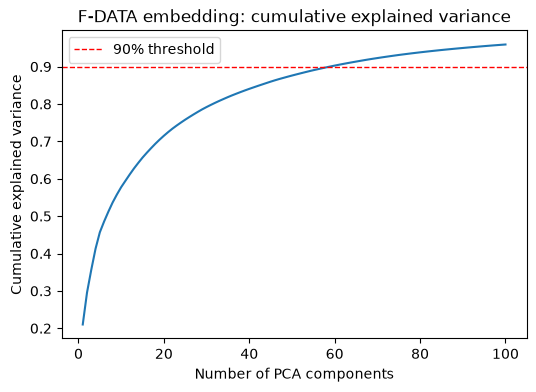


Using N_EMBEDDING_COMPONENTS=59 (90% explained variance) going forward


In [5]:
pca_variance_check = features.compute_embedding_explained_variance(fdata, max_components=100)

import numpy as np
cumulative = np.cumsum(pca_variance_check.explained_variance_ratio_)
for threshold in [0.80, 0.90, 0.95, 0.99]:
    n = features.n_components_for_variance(pca_variance_check, threshold)
    print(f"{threshold:.0%} variance -> {n} components")

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(cumulative) + 1), cumulative)
plt.axhline(0.90, color="r", linestyle="--", linewidth=1, label="90% threshold")
plt.xlabel("Number of PCA components")
plt.ylabel("Cumulative explained variance")
plt.title("F-DATA embedding: cumulative explained variance")
plt.legend()
plt.show()

N_EMBEDDING_COMPONENTS = features.n_components_for_variance(pca_variance_check, threshold=0.90)
print(f"\nUsing N_EMBEDDING_COMPONENTS={N_EMBEDDING_COMPONENTS} (90% explained variance) going forward")


In [6]:
fdata_emb_pca = features.reduce_fdata_embedding(fdata, n_components=N_EMBEDDING_COMPONENTS)
print(fdata_emb_pca.shape)
fdata_emb_pca.describe().T


(4721, 59)


,count,mean,std,min,25%,50%,75%,max
emb_pc_0,4721.0,2.506400e-07,0.306849,-0.594327,-0.105534,0.051105,0.223923,0.404360
emb_pc_1,4721.0,3.752277e-07,0.195714,-0.248134,-0.205161,-0.040867,0.153298,0.489009
emb_pc_2,4721.0,9.898335e-09,0.165471,-0.498391,-0.040616,0.034712,0.079842,0.229934
emb_pc_3,4721.0,-3.823990e-07,0.158814,-0.332501,-0.116131,-0.020610,0.112668,0.464881
emb_pc_4,4721.0,4.011856e-07,0.139996,-0.594866,-0.042149,0.032095,0.064365,0.240158
emb_pc_5,4721.0,-2.013503e-07,0.113794,-0.397146,-0.031860,-0.014403,0.049610,0.379020
emb_pc_6,4721.0,3.721724e-07,0.108630,-0.322839,-0.044961,-0.005279,0.025102,0.505336
emb_pc_7,4721.0,-3.191708e-08,0.105003,-0.389954,-0.058060,0.004499,0.049769,0.406550
emb_pc_8,4721.0,-3.473508e-07,0.097789,-0.341294,-0.021576,-0.003640,0.038492,0.343383
emb_pc_9,4721.0,1.010034e-09,0.093798,-0.415867,-0.026465,-0.004639,0.044460,0.331885


## Step 4: Historical rolling-stat features (Tier A)

Each user's mean `duration` over their *previous* jobs only (never the current job's own outcome — computed via `shift(1)` before the rolling window, per Decision #1's leakage discipline). With only 1 of F-DATA's 38 months present and a 5000-row dev sample, expect these to be sparse/noisy — this is expected, not a bug (see EXPERIMENT_TRACKER.md).

In [7]:
fdata_with_rolling = features.add_user_rolling_stat(fdata, "fdata", "duration", window=5)
pm100_with_rolling = features.add_user_rolling_stat(pm100, "pm100", "run_time", window=5)

n_fdata_available = fdata_with_rolling["duration_user_rolling_mean"].notna().sum()
n_pm100_available = pm100_with_rolling["run_time_user_rolling_mean"].notna().sum()
print(f"F-DATA: rolling stat available for {n_fdata_available}/{len(fdata_with_rolling)} jobs")
print(f"PM100: rolling stat available for {n_pm100_available}/{len(pm100_with_rolling)} jobs")

fdata_with_rolling[["usr", "adt", "duration", "duration_user_rolling_mean"]].head(10)


F-DATA: rolling stat available for 4426/4721 jobs
PM100: rolling stat available for 3717/3952 jobs


,usr,adt,duration,duration_user_rolling_mean
0,usr_1365,2022-02-01 00:12:11+09:00,51.0,44.2
1,usr_2448,2023-08-18 08:29:49+09:00,470.0,23.2
3,usr_341,2022-02-27 14:18:27+09:00,14.0,18.6
4,usr_1365,2022-02-07 06:34:36+09:00,69.0,69.8
5,usr_2111,2023-08-29 19:26:20+09:00,101.0,997.6
6,usr_1365,2022-02-08 17:43:14+09:00,95.0,122.6
7,usr_1365,2022-02-01 05:00:05+09:00,192.0,123.0
8,usr_244,2023-08-08 10:29:41+09:00,4.0,2404.0
9,usr_445,2022-02-02 11:45:17+09:00,541.0,NaN
10,usr_1365,2022-02-08 00:39:16+09:00,156.0,148.6


## Step 5: Target transforms (Decision #3)

log1p on all three targets per dataset (execution time, memory, power) — training happens in log-space, metrics get reported in both log-space and back-transformed real units. Sanity-checking the round-trip here (Decision #19) rather than assuming it.

In [8]:
for name, targets, df in [("F-DATA", features.FDATA_TARGETS, fdata), ("PM100", features.PM100_TARGETS, pm100)]:
    for target_name, col in targets.items():
        raw = df[col].dropna().to_numpy()
        if len(raw) and hasattr(raw[0], "__len__"):
            # PM100 power: array-valued, reduce to per-job mean first (see notebook 01)
            raw = np.array([np.mean(a) for a in raw])
        raw = raw[raw >= 0].astype(float)
        transformed = features.transform_target(raw)
        recovered = features.inverse_transform_target(transformed)
        metrics.expm1_round_trip_check(raw)
        print(f"{name} {target_name} ({col}): round-trip OK, n={len(raw)}, "
              f"raw range [{raw.min():.2f}, {raw.max():.2f}], "
              f"log1p range [{transformed.min():.2f}, {transformed.max():.2f}]")


F-DATA execution_time (duration): round-trip OK, n=4721, raw range [1.00, 255677.00], log1p range [0.69, 12.45]
F-DATA memory (mmszu): round-trip OK, n=4721, raw range [23789568.00, 29637017600.00], log1p range [16.98, 24.11]
F-DATA power (avgpcon): round-trip OK, n=4721, raw range [39.53, 784526.52], log1p range [3.70, 13.57]
PM100 execution_time (run_time): round-trip OK, n=3952, raw range [0.00, 86328.00], log1p range [0.00, 11.37]
PM100 memory (mem_alloc): round-trip OK, n=3952, raw range [1.00, 60800.00], log1p range [0.69, 11.02]
PM100 power (node_power_consumption): round-trip OK, n=3952, raw range [480.00, 173911.93], log1p range [6.18, 12.07]


## Summary

This notebook validates the feature-engineering pipeline end to end on the dev sample: exclusion, Tier A/B separation, embedding reduction, rolling-stat features, and target transforms all pass their sanity checks. Nothing here is yet the "final" feature matrix used for training — that assembly happens in notebooks 05-07, reusing these same `src/features.py` functions against the full dataset once available.